# 특장차 대기시간 분석

이 노트북은 `03_wait_time_data_preprocessing.ipynb`에서 생성한 특장차 분석용 데이터셋을 불러와 대기시간을 분석한다.

특장차는 `바로콜`, `전일접수`, `심야시간 사전예약`, `기타 예약성/미분류`가 함께 존재하므로 접수유형 후보별로 분석 대상을 분리한다. 정기접수는 고객 식별자가 없어 확정 분류하지 않고 `정기접수_가능패턴여부` 보조 플래그로만 확인한다.


In [58]:
import json
import platform
from pathlib import Path
import importlib

import statsmodels
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.regression as sns_regression

sns_regression = importlib.reload(sns_regression)

from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("statsmodels:", statsmodels.__version__)
print("seaborn:", sns.__version__)

statsmodels: 0.15.0
seaborn: 0.13.2


In [56]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

processed_dir = PROJECT_ROOT / "data" / "processed"

final_dataset_path = processed_dir / "특장차_대기시간_전처리_접수유형분류.csv"
final_summary_path = processed_dir / "특장차_대기시간_전처리_접수유형분류_요약.csv"

print("final_dataset_path", final_dataset_path.exists(), final_dataset_path)
print("final_summary_path", final_summary_path.exists(), final_summary_path)


final_dataset_path True /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류.csv
final_summary_path True /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류_요약.csv


In [57]:
datetime_cols = [
    "접수일시",
    "예정일시",
    "배차일시",
    "승차일시",
    "하차일시",
    "취소일시",
    "접수일자",
    "예정일자",
    "배차일자",
    "승차일자",
    "하차일자",
]

def read_special_dataset(path):
    df = pd.read_csv(path)
    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

df_special = read_special_dataset(final_dataset_path)
special_analysis_dataset_summary = pd.read_csv(final_summary_path)

request_type_col = "특장차_접수유형_후보_최종"
if request_type_col not in df_special.columns:
    request_type_col = "특장차_접수유형_후보_보완"

special_ride_valid = df_special[
    df_special["특장차_탑승완료_시간논리정상여부"].fillna(False)
].copy()

special_ride_baro_call = special_ride_valid[
    special_ride_valid[request_type_col].eq("바로콜 후보")
].copy()

special_ride_previous_day = special_ride_valid[
    special_ride_valid[request_type_col].eq("전일접수 후보")
].copy()

special_ride_night_reservation = special_ride_valid[
    special_ride_valid[request_type_col].eq("심야시간 사전예약 후보")
].copy()

special_ride_other = special_ride_valid[
    special_ride_valid[request_type_col].eq("기타 예약성/미분류")
].copy()

special_cancel = df_special[df_special["취소일시"].notna()].copy()

print(f"특장차 전처리 전체: {len(df_special):,}건")
print(f"특장차 탑승완료 정상: {len(special_ride_valid):,}건")
print(f"접수유형 분류 컬럼: {request_type_col}")
display(special_analysis_dataset_summary)


특장차 전처리 전체: 1,393,534건
특장차 탑승완료 정상: 1,164,430건
접수유형 분류 컬럼: 특장차_접수유형_후보_최종


,구분,건수,비율_전체대비(%),요약구분,비율(%)
0,특장차 전체 전처리 건수,1393534,100.00,분석용 데이터셋,NaN
1,탑승완료 정상 건수,1164430,83.56,분석용 데이터셋,NaN
2,바로콜 후보 건수,1099084,78.87,분석용 데이터셋,NaN
3,전일접수 후보 건수,48931,3.51,분석용 데이터셋,NaN
4,심야시간 사전예약 후보 건수,116,0.01,분석용 데이터셋,NaN
5,기타 예약성/미분류 건수,16299,1.17,분석용 데이터셋,NaN
6,정기접수 가능패턴 건수,135789,9.74,분석용 데이터셋,NaN
7,취소 전체 건수,228987,16.43,분석용 데이터셋,NaN
8,바로콜 후보,1099084,NaN,접수유형 후보 분포,78.87
9,승차완료 외/분류대상 아님,229104,NaN,접수유형 후보 분포,16.44


## 1. 전처리 결과 및 분석 데이터셋 재확인

분석에 들어가기 전에 전처리 결과와 분석용 데이터셋 건수를 확인한다. 특히 접수유형 후보별 승차 완료 데이터셋과 취소 데이터셋을 분리해서 사용한다.


In [59]:
# 코드 셀 목적: 특장차 분석용 데이터셋 건수와 핵심 대기시간 유효 표본 수를 재확인한다.

analysis_dataset_summary = pd.DataFrame({
    "데이터셋": [
        "df_special",
        "special_ride_valid",
        "special_ride_baro_call",
        "special_ride_previous_day",
        "special_ride_night_reservation",
        "special_ride_other",
        "special_cancel",
    ],
    "용도": [
        "특장차 전체 전처리 결과",
        "특장차 탑승완료 정상 건",
        "특장차 바로콜 후보 승차 대기시간 분석",
        "특장차 전일접수 후보 대기시간 분석",
        "특장차 심야시간 사전예약 후보 분석",
        "특장차 기타 예약성/미분류 확인",
        "특장차 취소 전체 분석",
    ],
    "건수": [
        len(df_special),
        len(special_ride_valid),
        len(special_ride_baro_call),
        len(special_ride_previous_day),
        len(special_ride_night_reservation),
        len(special_ride_other),
        len(special_cancel),
    ],
})

wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
    "접수_취소_분",
    "배차_취소_분",
    "배차_승차_분",
]

wait_valid_summary = pd.DataFrame({
    "컬럼명": wait_cols,
    "유효건수": [df_special[col].notna().sum() for col in wait_cols],
    "결측건수": [df_special[col].isna().sum() for col in wait_cols],
})

display(analysis_dataset_summary)
display(wait_valid_summary)


,데이터셋,용도,건수
0,df_special,특장차 전체 전처리 결과,1393534
1,special_ride_valid,특장차 탑승완료 정상 건,1164430
2,special_ride_baro_call,특장차 바로콜 후보 승차 대기시간 분석,1099084
3,special_ride_previous_day,특장차 전일접수 후보 대기시간 분석,48931
4,special_ride_night_reservation,특장차 심야시간 사전예약 후보 분석,116
5,special_ride_other,특장차 기타 예약성/미분류 확인,16299
6,special_cancel,특장차 취소 전체 분석,228987


,컬럼명,유효건수,결측건수
0,접수_배차_분,1215984,177550
1,접수_승차_분,1164483,229051
2,접수_취소_분,228987,1164547
3,배차_취소_분,51461,1342073
4,배차_승차_분,1164483,229051


## 2. 접수유형 후보별 기본 현황

접수유형 후보별 건수와 대기시간 분포를 비교한다. 특장차는 접수유형에 따라 `접수→승차`의 의미가 달라지므로 전체를 한 번에 해석하지 않는다.


In [60]:
# 코드 셀 목적: 접수유형 후보별 탑승완료 건수와 핵심 대기시간 요약을 확인한다.

request_type_summary = (
    special_ride_valid
    .groupby(request_type_col, observed=False)
    .agg(
        건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

request_type_summary["비율(%)"] = (
    request_type_summary["건수"] / request_type_summary["건수"].sum() * 100
)

display(request_type_summary.sort_values("건수", ascending=False))


,특장차_접수유형_후보_최종,건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수,비율(%)
1,바로콜 후보,1099084,11.975408,72.116748,33.419308,95.134233,17.854283,29.419167,94.388156
3,전일접수 후보,48931,1443.255933,1449.309500,1460.757283,1476.484833,18.457550,29.163450,4.202142
0,기타 예약성/미분류,16299,1086.536383,1814.475167,1105.370783,1847.506310,20.005617,33.518490,1.399741
2,심야시간 사전예약 후보,116,847.613833,1062.402083,872.354642,1091.093333,25.086892,39.032008,0.009962


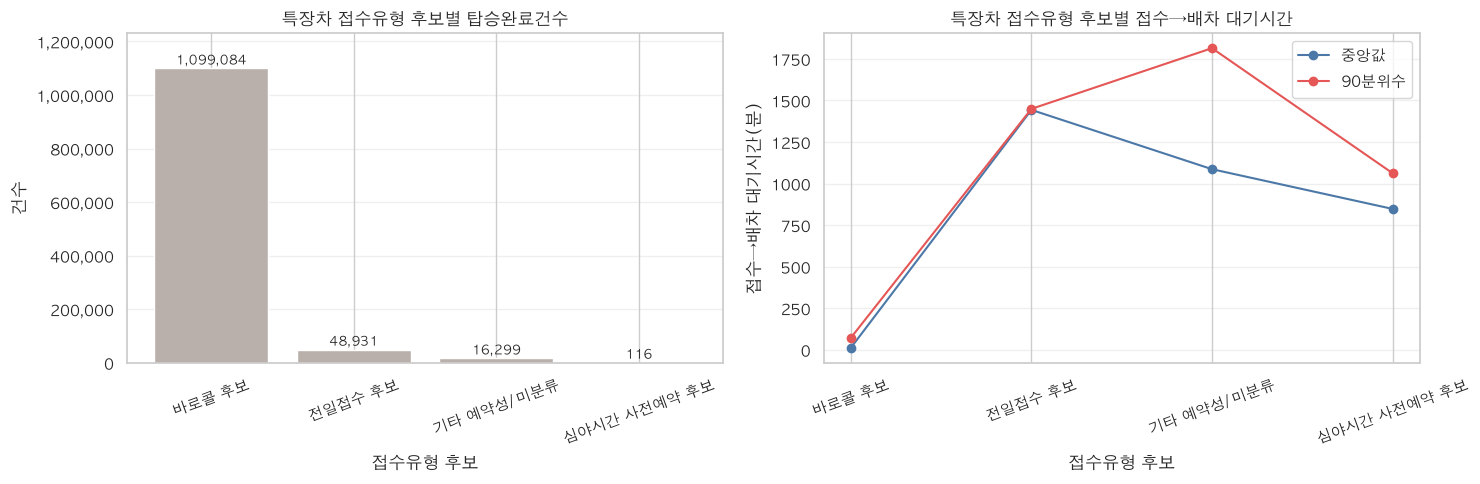

In [61]:
# 코드 셀 목적: 접수유형 후보별 건수와 접수→배차 90분위수를 함께 시각화한다.

from matplotlib.ticker import FuncFormatter

plot_data = request_type_summary.sort_values("건수", ascending=False).reset_index(drop=True)
x = range(len(plot_data))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(x, plot_data["건수"], color="#bab0ab")
for i, row in plot_data.iterrows():
    axes[0].text(
        i,
        row["건수"],
        f'{row["건수"]:,}',
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[0].set_title("특장차 접수유형 후보별 탑승완료건수")
axes[0].set_xlabel("접수유형 후보")
axes[0].set_ylabel("건수")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(plot_data[request_type_col], rotation=20)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{int(value):,}"))
axes[0].set_ylim(0, plot_data["건수"].max() * 1.12)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(x, plot_data["접수_배차_중앙값"], marker="o", label="중앙값", color="#4c78a8")
axes[1].plot(x, plot_data["접수_배차_90분위수"], marker="o", label="90분위수", color="#e45756")
axes[1].set_title("특장차 접수유형 후보별 접수→배차 대기시간")
axes[1].set_xlabel("접수유형 후보")
axes[1].set_ylabel("접수→배차 대기시간(분)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(plot_data[request_type_col], rotation=20)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. 특장차 바로콜 승차 대기시간 분석

바로콜 후보를 대상으로 `접수→배차`, `접수→승차`, `배차→승차`를 비교한다. 바로콜에서는 이용자가 체감하는 전체 대기시간인 `접수→승차`와, 공급 부족 가능성을 보여주는 `접수→배차`가 핵심 지표다.


In [62]:
# 코드 셀 목적: 특장차 바로콜 후보의 승차 대기시간 요약을 확인한다.

ride_wait_cols = ["접수_배차_분", "접수_승차_분", "배차_승차_분"]
baro_wait_summary = []

for col in ride_wait_cols:
    values = special_ride_baro_call[col].dropna()
    baro_wait_summary.append({
        "구간": col.replace("_", "→").replace("분", "").rstrip("→"),
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "99분위수": values.quantile(0.99),
        "최대값": values.max(),
    })

baro_wait_summary = pd.DataFrame(baro_wait_summary)
display(baro_wait_summary)


,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,99분위수,최대값
0,접수→배차,1099084,27.472058,11.975408,36.918754,72.116748,107.834617,142.376381,198.331383
1,접수→승차,1099084,46.270226,33.419308,57.332404,95.134233,133.938383,166.639232,199.990767
2,배차→승차,1099084,18.798168,17.854283,23.560887,29.419167,33.463898,42.765773,137.371950


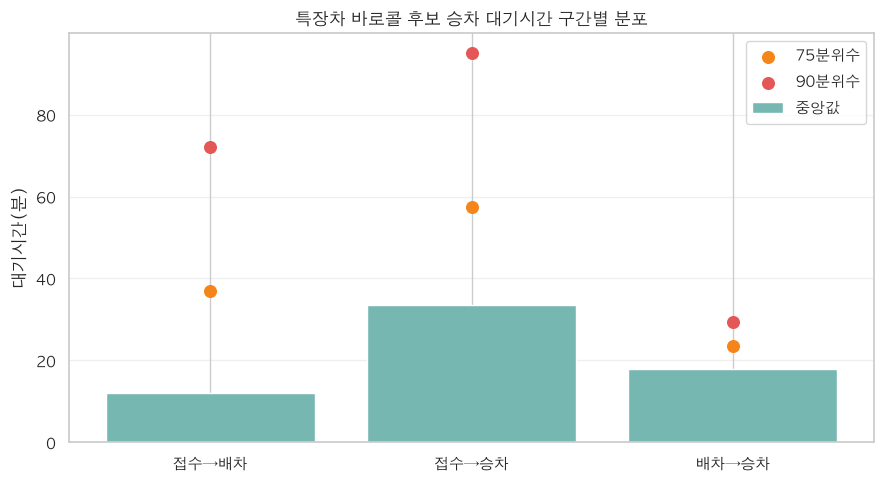

In [63]:
# 코드 셀 목적: 특장차 바로콜 후보의 대기시간 구간별 분포를 시각화한다.

plot_data = baro_wait_summary.copy()
x = range(len(plot_data))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, plot_data["중앙값"], color="#76b7b2", label="중앙값")
ax.scatter(x, plot_data["75분위수"], color="#f58518", s=70, zorder=3, label="75분위수")
ax.scatter(x, plot_data["90분위수"], color="#e45756", s=70, zorder=3, label="90분위수")
ax.set_title("특장차 바로콜 후보 승차 대기시간 구간별 분포")
ax.set_ylabel("대기시간(분)")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["구간"])
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 3-1. 바로콜 접수시간대별 접수→배차 대기시간 상세

특장차 바로콜 후보만 대상으로 접수시간대별 `접수→배차` 대기시간을 다시 확인한다.

선그래프는 시간대별 중앙값, 75분위수, 90분위수 흐름을 보여준다. 아래 히트맵은 요일·접수시간대별 90분위수와 승차완료건수를 함께 보여주므로, 장시간 대기가 특정 요일 문제인지 시간대 문제인지 구분하는 데 사용한다.


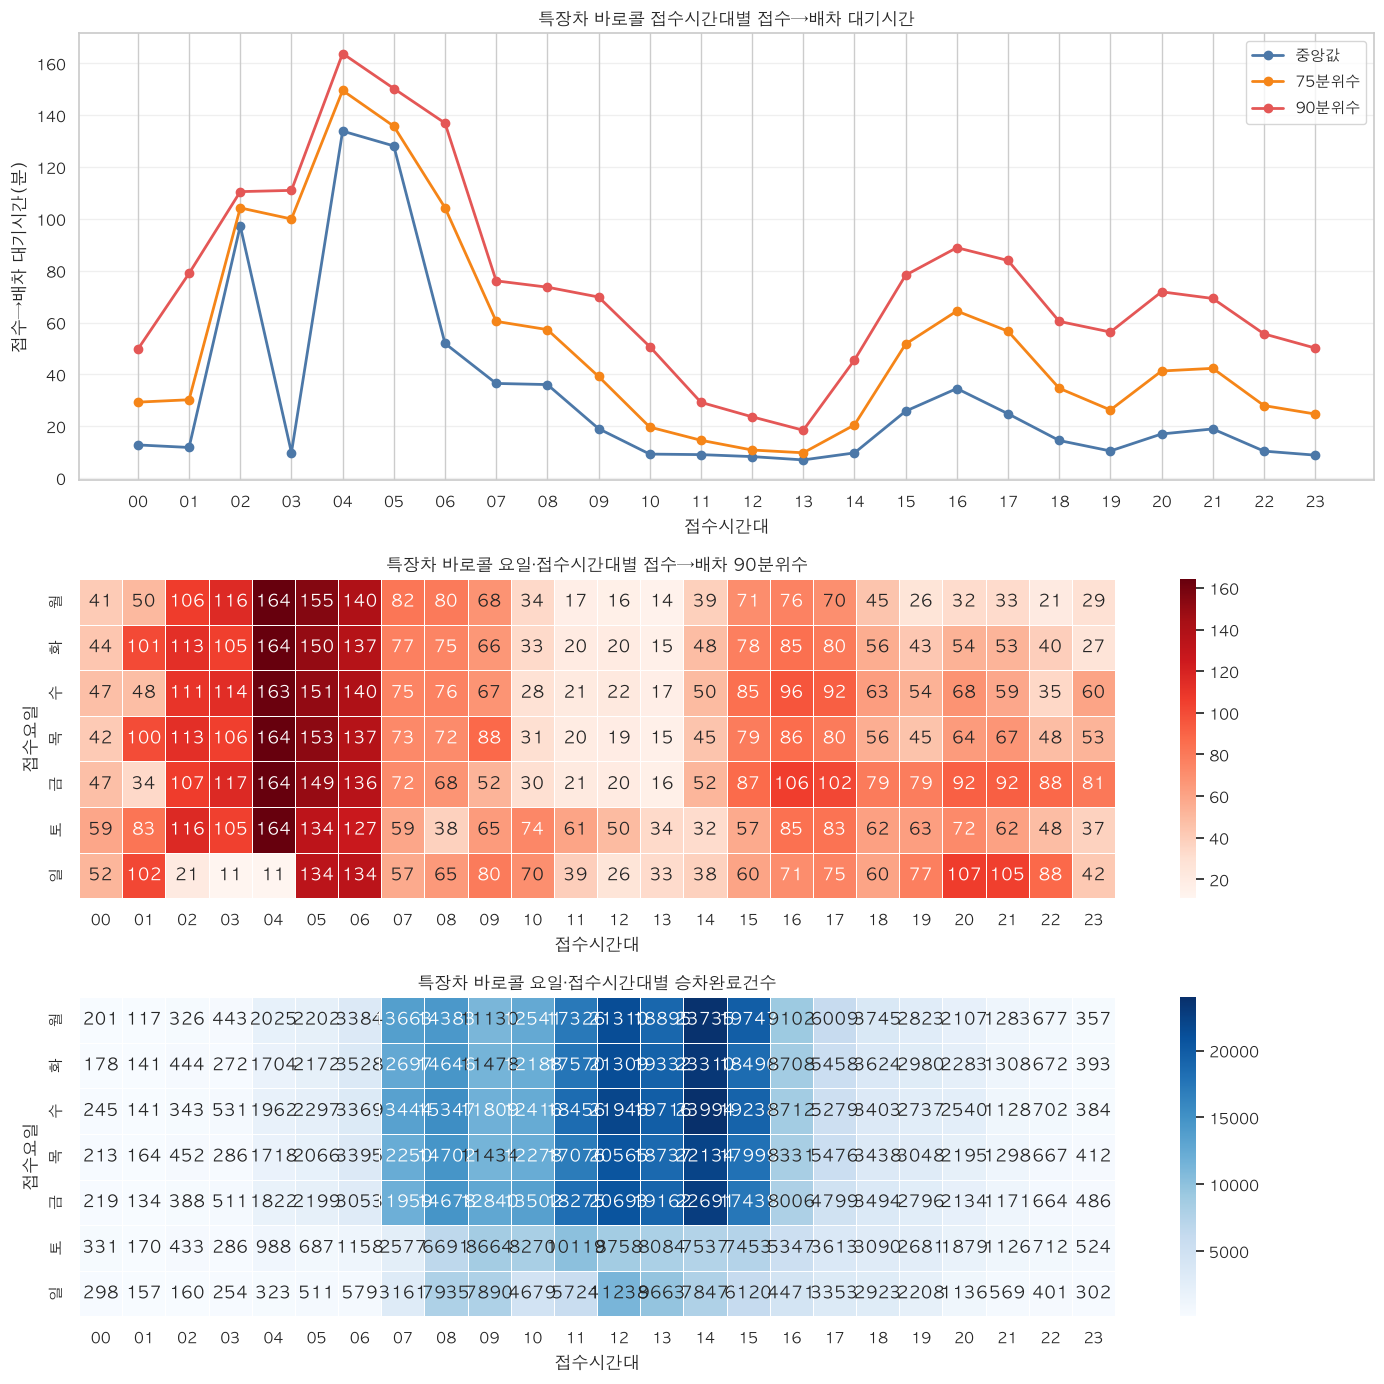

In [64]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 접수→배차 대기시간과 요일·시간대 히트맵을 함께 시각화한다.

baro_data = special_ride_baro_call.copy()

baro_data["접수일시"] = pd.to_datetime(baro_data["접수일시"], errors="coerce")
baro_data["접수시간대_HH"] = baro_data["접수일시"].dt.strftime("%H")
baro_data["접수_배차_분"] = pd.to_numeric(baro_data["접수_배차_분"], errors="coerce")

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

baro_dispatch_by_hour = (
    baro_data
    .dropna(subset=["접수시간대_HH", "접수_배차_분"])
    .groupby("접수시간대_HH", observed=False)
    .agg(
        건수=("접수_배차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_75분위수=("접수_배차_분", lambda x: x.quantile(0.75)),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
    .sort_values("접수시간대_HH")
)

dispatch_p90_heatmap = (
    baro_data
    .dropna(subset=["접수요일", "접수시간대_HH", "접수_배차_분"])
    .pivot_table(
        index="접수요일",
        columns="접수시간대_HH",
        values="접수_배차_분",
        aggfunc=lambda x: x.quantile(0.90),
        observed=False,
    )
    .reindex(weekday_order)
)

dispatch_count_heatmap = (
    baro_data
    .dropna(subset=["접수요일", "접수시간대_HH", "접수_배차_분"])
    .pivot_table(
        index="접수요일",
        columns="접수시간대_HH",
        values="접수_배차_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(weekday_order)
)

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[1.4, 1, 1])

ax_line = fig.add_subplot(gs[0, 0])
ax_heat1 = fig.add_subplot(gs[1, 0])
ax_heat2 = fig.add_subplot(gs[2, 0])

ax_line.plot(
    baro_dispatch_by_hour["접수시간대_HH"],
    baro_dispatch_by_hour["접수_배차_중앙값"],
    marker="o",
    linewidth=2,
    color="#4c78a8",
    label="중앙값",
)
ax_line.plot(
    baro_dispatch_by_hour["접수시간대_HH"],
    baro_dispatch_by_hour["접수_배차_75분위수"],
    marker="o",
    linewidth=2,
    color="#f58518",
    label="75분위수",
)
ax_line.plot(
    baro_dispatch_by_hour["접수시간대_HH"],
    baro_dispatch_by_hour["접수_배차_90분위수"],
    marker="o",
    linewidth=2,
    color="#e45756",
    label="90분위수",
)

ax_line.set_title("특장차 바로콜 접수시간대별 접수→배차 대기시간")
ax_line.set_xlabel("접수시간대")
ax_line.set_ylabel("접수→배차 대기시간(분)")
ax_line.grid(axis="y", alpha=0.3)
ax_line.legend()

sns.heatmap(
    dispatch_p90_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=ax_heat1,
)
ax_heat1.set_title("특장차 바로콜 요일·접수시간대별 접수→배차 90분위수")
ax_heat1.set_xlabel("접수시간대")
ax_heat1.set_ylabel("접수요일")

sns.heatmap(
    dispatch_count_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax_heat2,
)
ax_heat2.set_title("특장차 바로콜 요일·접수시간대별 승차완료건수")
ax_heat2.set_xlabel("접수시간대")
ax_heat2.set_ylabel("접수요일")

plt.tight_layout()
plt.show()


## 3-2. 바로콜 접수→배차 대기시간 전체 분포

특장차 바로콜 후보의 `접수→배차` 대기시간 전체 분포를 확인한다.

히스토그램은 전체 대기시간이 어느 구간에 몰리는지 보여주고, 히트맵은 접수시간대별로 장시간 대기 구간이 어디에 집중되는지 보여준다. 두 번째 히트맵은 `0~10분`을 제외해 장시간 대기 패턴을 더 잘 보이게 한다.


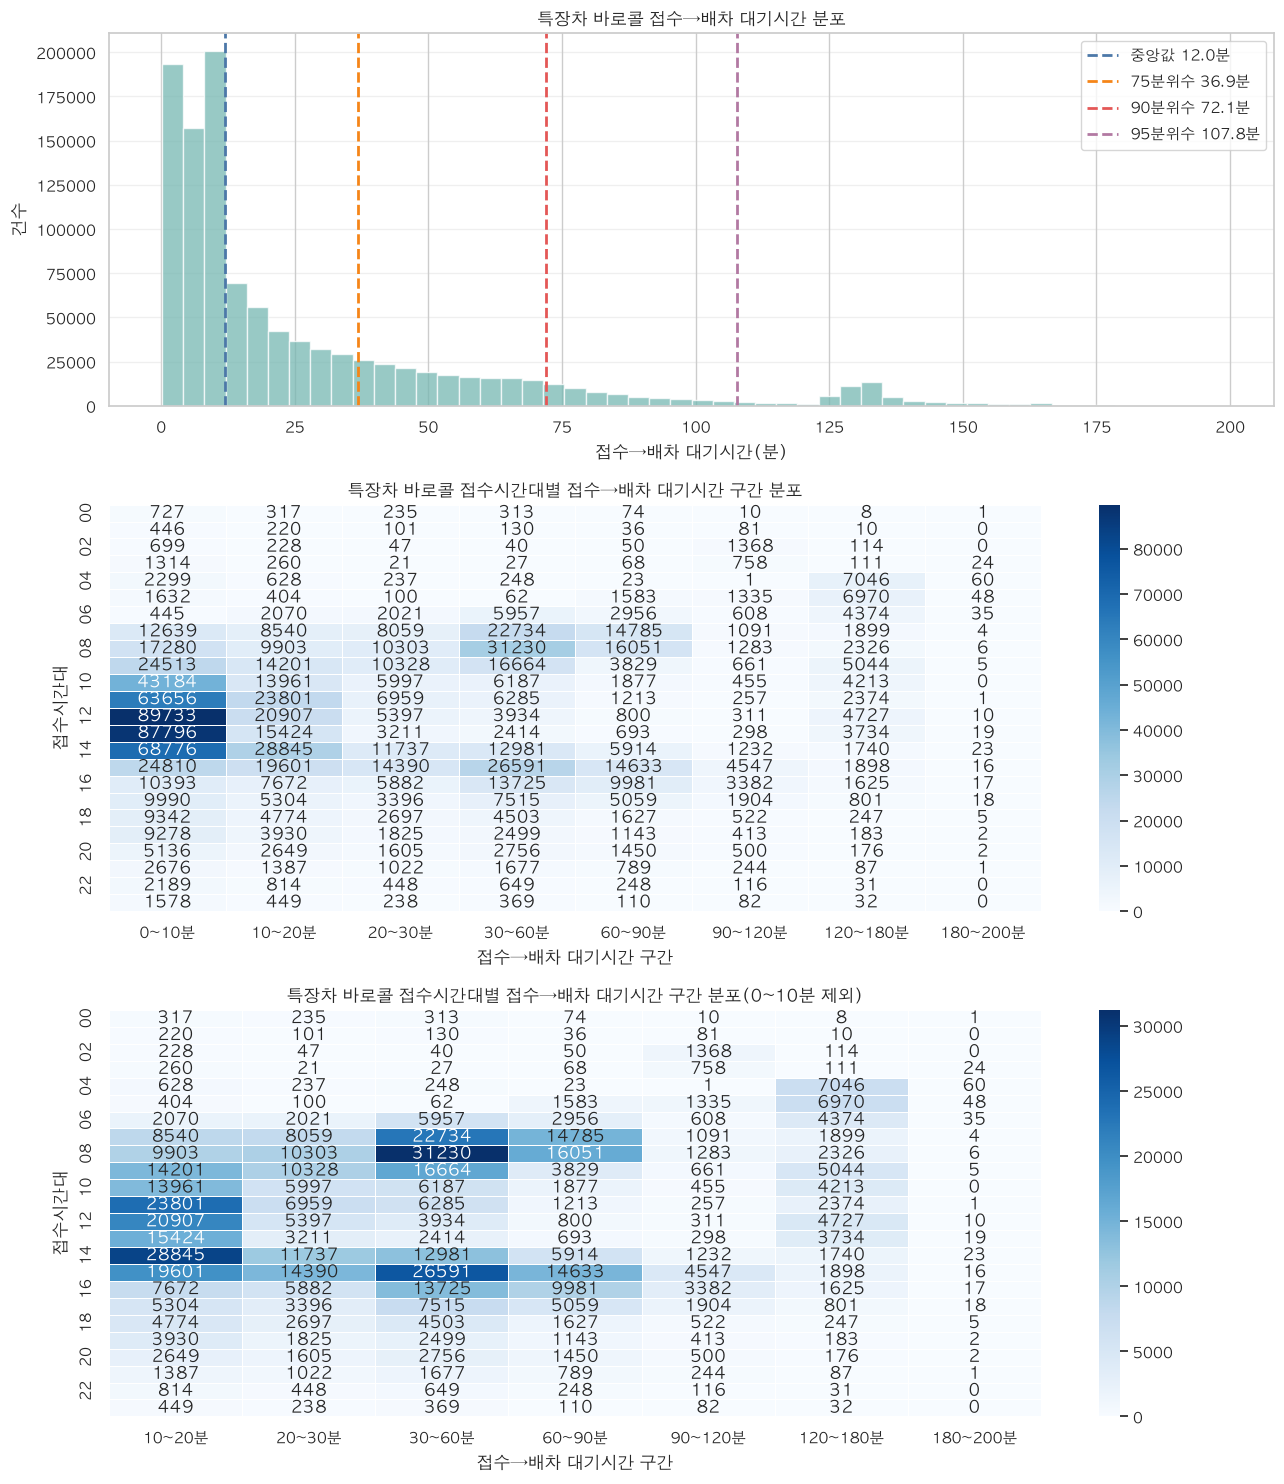

In [65]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수→배차 대기시간 전체 분포와 시간대별 구간 분포를 시각화한다.

baro_data = special_ride_baro_call.copy()

baro_data["접수일시"] = pd.to_datetime(baro_data["접수일시"], errors="coerce")
baro_data["접수시간대_HH"] = baro_data["접수일시"].dt.strftime("%H")
baro_data["접수_배차_분"] = pd.to_numeric(baro_data["접수_배차_분"], errors="coerce")

baro_data = baro_data.dropna(subset=["접수시간대_HH", "접수_배차_분"]).copy()
baro_data = baro_data[
    (baro_data["접수_배차_분"] >= 0)
    & (baro_data["접수_배차_분"] <= 200)
].copy()

quantiles = {
    "중앙값": baro_data["접수_배차_분"].quantile(0.50),
    "75분위수": baro_data["접수_배차_분"].quantile(0.75),
    "90분위수": baro_data["접수_배차_분"].quantile(0.90),
    "95분위수": baro_data["접수_배차_분"].quantile(0.95),
}

wait_bins = [0, 10, 20, 30, 60, 90, 120, 180, 200]
wait_labels = [
    "0~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
    "180~200분",
]

baro_data["접수_배차_구간"] = pd.cut(
    baro_data["접수_배차_분"],
    bins=wait_bins,
    labels=wait_labels,
    right=True,
    include_lowest=True,
)

heatmap_data = (
    baro_data
    .pivot_table(
        index="접수시간대_HH",
        columns="접수_배차_구간",
        values="접수_배차_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(columns=wait_labels)
    .fillna(0)
)

heatmap_data_without_short_wait = (
    baro_data[baro_data["접수_배차_구간"].ne("0~10분")]
    .pivot_table(
        index="접수시간대_HH",
        columns="접수_배차_구간",
        values="접수_배차_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(columns=wait_labels[1:])
    .fillna(0)
)

fig = plt.figure(figsize=(13, 15))
gs = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.2, 1.2])
ax_hist = fig.add_subplot(gs[0, 0])
ax_heat_all = fig.add_subplot(gs[1, 0])
ax_heat_long = fig.add_subplot(gs[2, 0])

ax_hist.hist(
    baro_data["접수_배차_분"],
    bins=50,
    color="#76b7b2",
    alpha=0.75,
    edgecolor="white",
)

line_colors = {
    "중앙값": "#4c78a8",
    "75분위수": "#f58518",
    "90분위수": "#e45756",
    "95분위수": "#b279a2",
}

for label, value in quantiles.items():
    ax_hist.axvline(
        value,
        color=line_colors[label],
        linestyle="--",
        linewidth=2,
        label=f"{label} {value:.1f}분",
    )

ax_hist.set_title("특장차 바로콜 접수→배차 대기시간 분포")
ax_hist.set_xlabel("접수→배차 대기시간(분)")
ax_hist.set_ylabel("건수")
ax_hist.grid(axis="y", alpha=0.3)
ax_hist.legend()

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax_heat_all,
)
ax_heat_all.set_title("특장차 바로콜 접수시간대별 접수→배차 대기시간 구간 분포")
ax_heat_all.set_xlabel("접수→배차 대기시간 구간")
ax_heat_all.set_ylabel("접수시간대")

sns.heatmap(
    heatmap_data_without_short_wait,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax_heat_long,
)
ax_heat_long.set_title("특장차 바로콜 접수시간대별 접수→배차 대기시간 구간 분포(0~10분 제외)")
ax_heat_long.set_xlabel("접수→배차 대기시간 구간")
ax_heat_long.set_ylabel("접수시간대")

plt.tight_layout()
plt.show()


## 4. 전일접수 후보 대기시간 분석

전일접수 후보는 접수 시점과 실제 탑승 예정시각 사이에 하루 정도의 간격이 있으므로, `접수→배차`나 `접수→승차`를 일반적인 대기시간으로 해석하면 안 된다.

전일접수에서 `예정일시`는 탑승예정시간에 가깝게 해석한다. 따라서 배차가 예정시각보다 얼마나 먼저 잡혔는지를 보려면 `배차일시 - 예정일시`가 아니라 `예정일시 - 배차일시` 방향으로 계산하는 것이 더 직관적이다.

분석 지표는 다음처럼 구분한다.

```text
배차여유_분 = 예정일시 - 배차일시
승차지연_분 = 승차일시 - 예정일시
배차_승차_분 = 승차일시 - 배차일시
```

해석 기준은 다음과 같다.

```text
배차여유_분 > 0  → 예정시각보다 먼저 배차됨
배차여유_분 = 0  → 예정시각에 배차됨
배차여유_분 < 0  → 예정시각보다 늦게 배차됨

승차지연_분 > 0  → 예정시각보다 늦게 승차함
승차지연_분 = 0  → 예정시각에 승차함
승차지연_분 < 0  → 예정시각보다 먼저 승차함
```

```text
배차여유_분이 크다 → 차량이 예정시각보다 충분히 먼저 배차됨
배차여유_분이 0에 가깝다 → 예정시각 근처에 배차됨
배차여유_분이 음수다 → 예정시각 이후에 배차됨, 배차 지연 가능성
승차지연_분이 크다 → 예정시각보다 실제 승차가 늦어짐
배차_승차_분이 크다 → 배차 후 차량 접근 또는 승차 완료까지 시간이 오래 걸림.
```


,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,최소값,최대값
0,배차여유,48931,-5.523625,-6.026617,-2.555967,1.566550,5.092858,-99.394050,1428.131950
1,승차지연,48931,24.833721,23.808383,30.302367,37.202617,42.238475,-1409.625783,122.631883
2,배차→승차,48931,19.310096,18.457550,23.792750,29.163450,32.869833,0.000000,121.619333


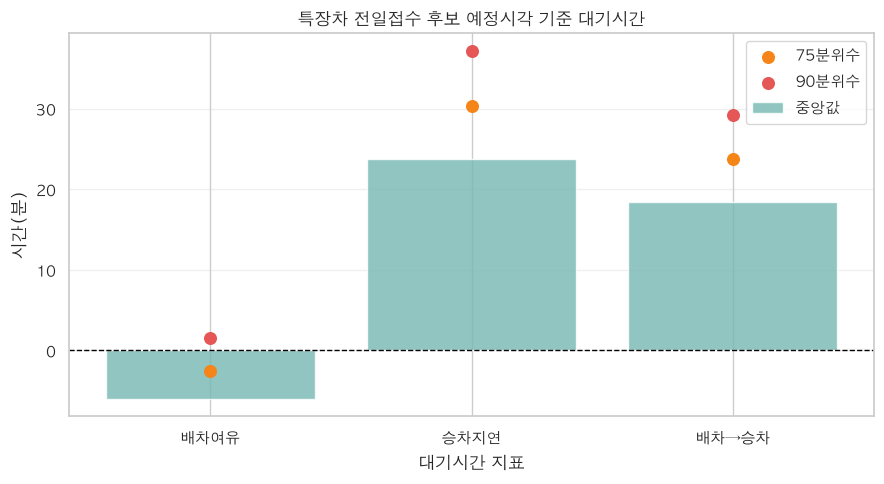

In [68]:
# 코드 셀 목적: 전일접수 후보의 예정시각 기준 배차여유·승차지연·배차후 승차시간을 확인한다.

previous_day_data = special_ride_previous_day.copy()

previous_day_data["예정일시"] = pd.to_datetime(previous_day_data["예정일시"], errors="coerce")
previous_day_data["배차일시"] = pd.to_datetime(previous_day_data["배차일시"], errors="coerce")
previous_day_data["승차일시"] = pd.to_datetime(previous_day_data["승차일시"], errors="coerce")
previous_day_data["배차_승차_분"] = pd.to_numeric(
    previous_day_data["배차_승차_분"],
    errors="coerce",
)

previous_day_data["배차여유_분"] = (
    previous_day_data["예정일시"] - previous_day_data["배차일시"]
).dt.total_seconds() / 60

previous_day_data["승차지연_분"] = (
    previous_day_data["승차일시"] - previous_day_data["예정일시"]
).dt.total_seconds() / 60

previous_day_wait_cols = ["배차여유_분", "승차지연_분", "배차_승차_분"]
previous_day_wait_labels = {
    "배차여유_분": "배차여유",
    "승차지연_분": "승차지연",
    "배차_승차_분": "배차→승차",
}

previous_day_wait_summary = []

for col in previous_day_wait_cols:
    values = previous_day_data[col].dropna()
    previous_day_wait_summary.append({
        "구간": previous_day_wait_labels[col],
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "최소값": values.min(),
        "최대값": values.max(),
    })

previous_day_wait_summary = pd.DataFrame(previous_day_wait_summary)
display(previous_day_wait_summary)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(previous_day_wait_summary))

ax.bar(
    x,
    previous_day_wait_summary["중앙값"],
    color="#76b7b2",
    alpha=0.8,
    label="중앙값",
)

ax.scatter(
    x,
    previous_day_wait_summary["75분위수"],
    color="#f58518",
    s=70,
    label="75분위수",
    zorder=3,
)

ax.scatter(
    x,
    previous_day_wait_summary["90분위수"],
    color="#e45756",
    s=70,
    label="90분위수",
    zorder=3,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("특장차 전일접수 후보 예정시각 기준 대기시간")
ax.set_xlabel("대기시간 지표")
ax.set_ylabel("시간(분)")
ax.set_xticks(list(x))
ax.set_xticklabels(previous_day_wait_summary["구간"])
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

1. `배차여유` 중앙값이 음수
   - `배차여유_분 = 예정일시 - 배차일시` => 음수는 예정시각보다 늦게 배차됐다는 뜻
   - 중앙값이 약 `-6분` => 전일접수 후보의 절반 정도는 예정시각보다 약 6분 이상 늦게 배차됨
   - 다만 90분위수는 양수 => 일부 건은 예정시각보다 미리 배차됨

2. `승차지연` 중앙값은 약 24분
   - `승차지연_분 = 승차일시 - 예정일시` => 실제 승차는 예정시각보다 보통 20분 늦게 이루어짐
   - 90분위수는 약 37분 => 상위 10%는 예정시각보다 35분 이상 늦게 승차

3. `배차→승차` 중앙값은 약 18분
   - 배차 후 실제 승차까지도 일정 시간이 걸림
   - `승차지연`의 상당 부분은 배차 이후 차량 접근 및 승차 완료 과정에서 발생하는 것으로 해석 가능

전일접수 후보의 예정시각 기준 대기시간을 보면, `배차여유` 중앙값은 음수로 나타나 예정시각보다 배차가 다소 늦게 이루어지는 경향이 있다. 다만 지연 폭은 중앙값 기준 약 6분 수준으로 크지는 않다.

반면 `승차지연` 중앙값은 약 24분, 90분위수는 약 37분으로 나타나 실제 승차는 예정시각보다 20~30분가량 늦어지는 경우가 많다. `배차→승차` 중앙값도 약 18분으로 나타나, 전일접수 후보의 체감 대기시간은 배차 자체의 지연뿐 아니라 배차 이후 차량 접근 및 승차 완료 과정에서 주로 발생하는 것으로 해석된다.

## 4-1. 전일접수 후보 예정 기준 대기시간 분포

전일접수 후보는 접수시각보다 탑승예정시간인 `예정일시`를 기준으로 실제 지연을 해석한다.

`예정대비_배차_분`과 `예정대비_승차_분`은 각각 `배차일시 - 예정일시`, `승차일시 - 예정일시`로 계산한다. 양수는 예정시각보다 늦은 배차/승차, 음수는 예정시각보다 이른 배차/승차를 의미한다.


,대기시간구간,건수,평균,중앙값,p75,p90,p95,최소값,최대값
0,배차_승차_분,48931,19.310096,18.457550,23.792750,29.16345,32.869833,0.000000,121.619333
1,배차여유_분,48897,-5.540977,-6.021883,-2.554000,1.56687,5.092773,-59.942283,25.785167
2,승차지연_분,48929,24.892240,23.808617,30.302783,37.20267,42.238980,-8.009550,122.631883


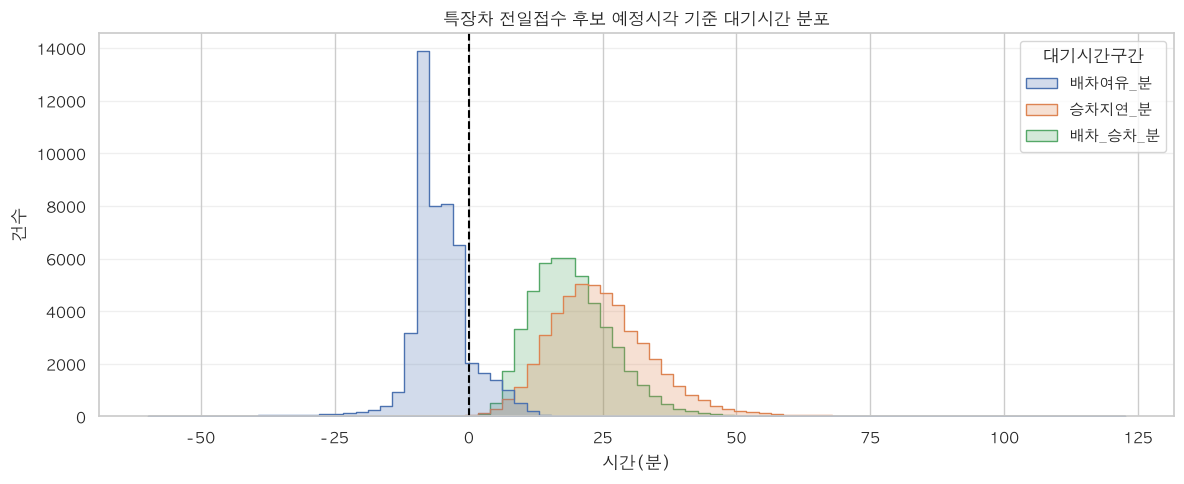

In [69]:
# 코드 셀 목적: 특장차 전일접수 후보의 예정시각 기준 배차여유·승차지연·배차후 승차시간 분포를 히스토그램으로 시각화한다.

previous_day_data = special_ride_previous_day.copy()

previous_day_data["예정일시"] = pd.to_datetime(previous_day_data["예정일시"], errors="coerce")
previous_day_data["배차일시"] = pd.to_datetime(previous_day_data["배차일시"], errors="coerce")
previous_day_data["승차일시"] = pd.to_datetime(previous_day_data["승차일시"], errors="coerce")
previous_day_data["배차_승차_분"] = pd.to_numeric(
    previous_day_data["배차_승차_분"],
    errors="coerce",
)

previous_day_data["배차여유_분"] = (
    previous_day_data["예정일시"] - previous_day_data["배차일시"]
).dt.total_seconds() / 60

previous_day_data["승차지연_분"] = (
    previous_day_data["승차일시"] - previous_day_data["예정일시"]
).dt.total_seconds() / 60

previous_day_wait_long = (
    previous_day_data[["배차여유_분", "승차지연_분", "배차_승차_분"]]
    .melt(var_name="대기시간구간", value_name="대기시간(분)")
    .dropna()
)

previous_day_wait_long = previous_day_wait_long[
    previous_day_wait_long["대기시간(분)"].between(-60, 180)
].copy()

summary = (
    previous_day_wait_long
    .groupby("대기시간구간", observed=False)
    .agg(
        건수=("대기시간(분)", "count"),
        평균=("대기시간(분)", "mean"),
        중앙값=("대기시간(분)", "median"),
        p75=("대기시간(분)", lambda x: x.quantile(0.75)),
        p90=("대기시간(분)", lambda x: x.quantile(0.90)),
        p95=("대기시간(분)", lambda x: x.quantile(0.95)),
        최소값=("대기시간(분)", "min"),
        최대값=("대기시간(분)", "max"),
    )
    .reset_index()
)

display(summary)

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=previous_day_wait_long,
    x="대기시간(분)",
    hue="대기시간구간",
    bins=80,
    element="step",
    stat="count",
    common_norm=False,
    ax=ax,
)

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="예정시각")
ax.set_title("특장차 전일접수 후보 예정시각 기준 대기시간 분포")
ax.set_xlabel("시간(분)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

1. 파란색 `배차여유_분`은 대부분 `-10~0분` 근처에 몰려 있음
   - `배차여유_분 = 예정일시 - 배차일시`이므로 => 음수는 예정시각보다 늦게 배차됨을 의미
   - 전일접수는 차량이 예정시각보다 넉넉히 먼저 배차되기보다는 예정시각 직전~직후에 배차되는 경우가 많음
   - 특히 분포 중심이 0보다 왼쪽 => 조기 배차보다는 예정시각 약간 이후 배차가 더 일반적인 것으로 해석

2. 초록색 `배차_승차_분`은 `10~25분` 사이에 가장 많이 분포
   - 배차 후 실제 승차까지 차량 접근 또는 탑승 완료 시간이 붙는 구조

3. 주황색 `승차지연_분`은 `15~30분` 부근에 몰려 있음
   - `승차지연_분 = 승차일시 - 예정일시` => 실제 승차는 예정시각보다 보통 20분 전후 늦게 이루어지는 것으로 볼 수 있음
   - 이 값은 `배차여유_분`이 음수인 점과 `배차→승차` 시간이 더해져 만들어진 결과로 해석됨

전일접수 후보의 예정시각 기준 대기시간 분포를 보면, `배차여유_분`은 -10~0분 구간에 집중되어 있어 차량이 예정시각보다 미리 배차되기보다는 예정시각 직전 또는 직후에 배차되는 경향이 나타났다. 특히 분포 중심이 0보다 왼쪽에 있어, 예정시각 이후 배차되는 사례가 더 일반적인 것으로 보인다.

반면 `배차_승차_분`은 10~25분 구간에 집중되어 있으며, 이에 따라 `승차지연_분`은 15~30분 구간에 주로 분포한다. 이는 전일접수 후보의 실제 승차 지연이 예정시각 이후 배차와 배차 후 차량 접근 시간이 결합되어 발생함을 시사한다.

## 4-2. 전일접수 후보 예정시간대별 대기시간 구간 히트맵

전일접수 후보의 예정시간대별 대기시간 구간 분포를 히트맵으로 확인한다.

숫자는 해당 예정시간대와 대기시간 구간에 들어간 탑승완료 건수다. `예정대비_배차_분`, `예정대비_승차_분`, `배차_승차_분`을 나누어 보면 지연이 예정시각 대비 배차 단계에서 생기는지, 배차 이후 승차 단계에서 생기는지 구분할 수 있다.


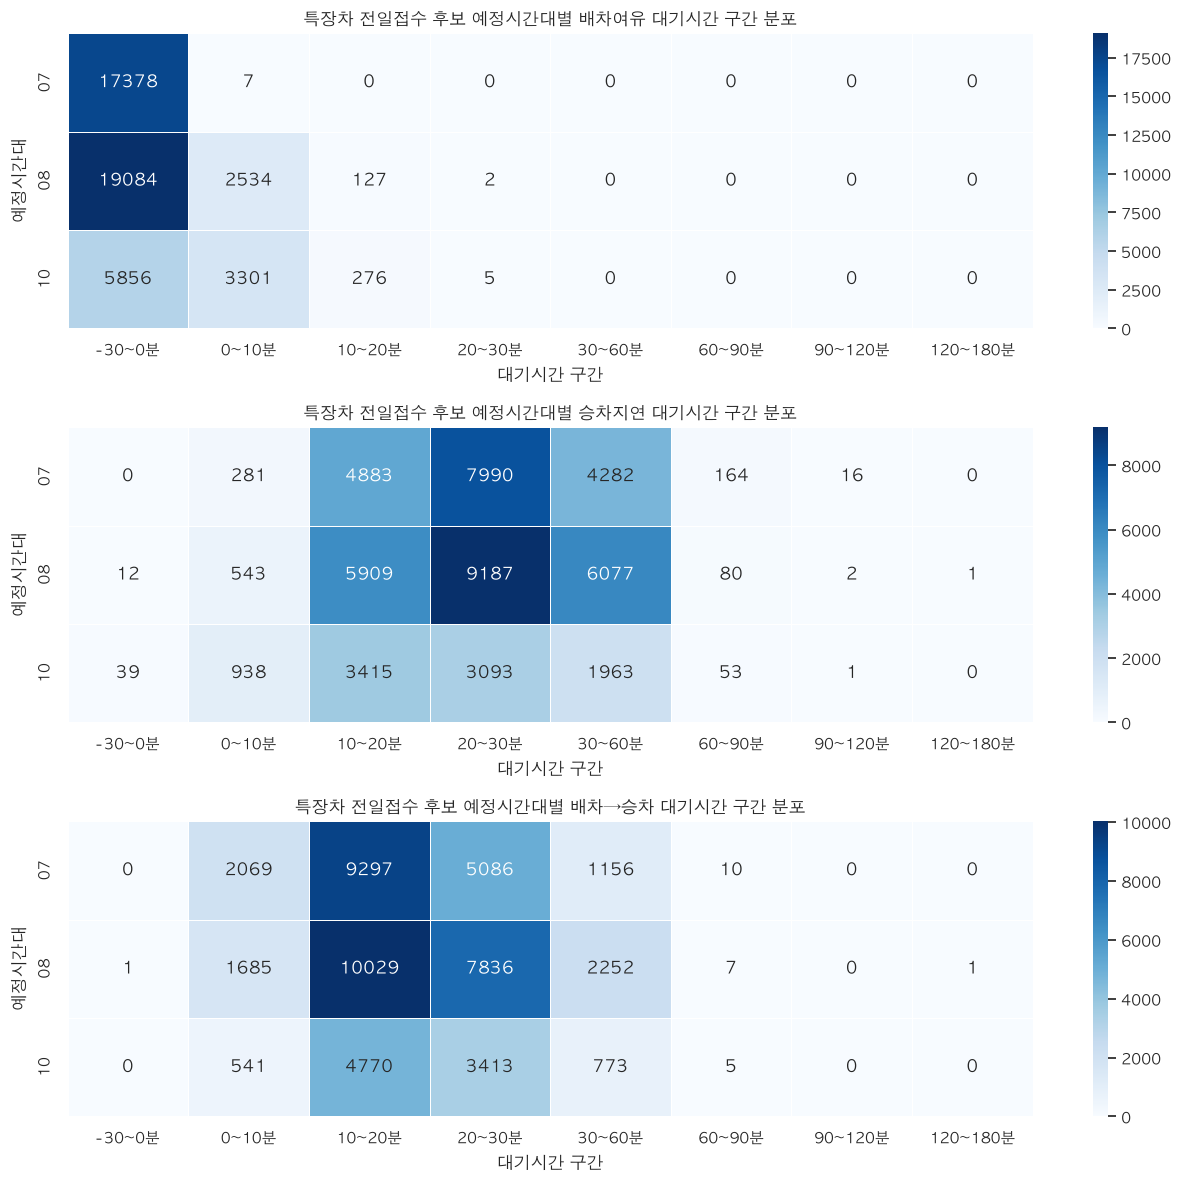

In [71]:
# 코드 셀 목적: 특장차 전일접수 후보의 예정시간대별 배차여유·승차지연·배차후 승차시간 구간 분포를 히트맵으로 시각화한다.

previous_day_heatmap_data = previous_day_data.copy()

previous_day_heatmap_data["예정일시"] = pd.to_datetime(
    previous_day_heatmap_data["예정일시"],
    errors="coerce",
)
previous_day_heatmap_data["예정시간대_HH"] = (
    previous_day_heatmap_data["예정일시"].dt.strftime("%H")
)

previous_day_heatmap_data["배차여유_분"] = pd.to_numeric(
    previous_day_heatmap_data["배차여유_분"],
    errors="coerce",
)
previous_day_heatmap_data["승차지연_분"] = pd.to_numeric(
    previous_day_heatmap_data["승차지연_분"],
    errors="coerce",
)
previous_day_heatmap_data["배차_승차_분"] = pd.to_numeric(
    previous_day_heatmap_data["배차_승차_분"],
    errors="coerce",
)

wait_bins = [-30, 0, 10, 20, 30, 60, 90, 120, 180]
wait_labels = [
    "-30~0분",
    "0~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
]

heatmap_specs = [
    ("배차여유_분", "배차여유"),
    ("승차지연_분", "승차지연"),
    ("배차_승차_분", "배차→승차"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

for ax, (col, title) in zip(axes, heatmap_specs):
    plot_data = previous_day_heatmap_data.dropna(
        subset=["예정시간대_HH", col]
    ).copy()

    plot_data["대기시간구간"] = pd.cut(
        plot_data[col],
        bins=wait_bins,
        labels=wait_labels,
        right=True,
        include_lowest=True,
    )

    heatmap_data = (
        plot_data
        .dropna(subset=["대기시간구간"])
        .pivot_table(
            index="예정시간대_HH",
            columns="대기시간구간",
            values=col,
            aggfunc="count",
            observed=False,
        )
        .reindex(columns=wait_labels)
        .fillna(0)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        linewidths=0.5,
        ax=ax,
    )

    ax.set_title(f"특장차 전일접수 후보 예정시간대별 {title} 대기시간 구간 분포")
    ax.set_xlabel("대기시간 구간")
    ax.set_ylabel("예정시간대")

plt.tight_layout()
plt.show()

1. `배차여유`는 대부분 음수, 예정시각 이후 배차가 많음
   - 첫 번째 히트맵을 보면 `배차여유`는 `-30~0분` 구간에 가장 많이 몰려 있음
   - 전일접수 후보는 대부분 예정시각보다 `0~30분` 늦게 배차되는 구조. 특히 07시와 08시에 이 패턴이 강하게 나타남
   - 다만 08시와 10시는 `0~10분` 구간도 어느 정도 존재 => 예정시각보다 `0~10분` 먼저 배차된 건으로 해석

2. `승차지연`은 `20~30분` 구간이 중심
   - 두 번째 히트맵을 보면 `승차지연`은 대체로 `20~30분` 구간에 가장 많이 몰려 있음
   - 실제 승차는 예정시각보다 보통 `20~30분` 정도 늦어지는 경우가 많음. 10시는 07시·08시보다 약간 짧아서 `10~20분` 구간도 많이 나타남

3. `배차→승차`는 `10~20분` 또는 `20~30분` 구간이 중심
   - 세 번째 히트맵은 배차 이후 실제 승차까지 걸린 시간
   - 배차된 뒤 실제 승차까지는 대체로 `10~30분` 정도 걸리는 것으로 해석

## 5. 심야시간 사전예약 후보 분석

심야시간 사전예약 후보는 월별 분포와 시간대별 최대 3명 기준을 검증한다. 이 기준은 후보 제외 조건이 아니라 운영 기준과 데이터가 얼마나 맞는지 확인하는 지표다.


In [72]:
# 코드 셀 목적: 심야시간 사전예약 후보의 월별·시간대별 분포와 3명 기준 초과 여부를 확인한다.

night_data = special_ride_night_reservation.copy()

if "승차일시" not in night_data.columns:
    raise KeyError("승차일시 컬럼이 없습니다.")

night_data["승차일시"] = pd.to_datetime(night_data["승차일시"], errors="coerce")
night_data = night_data.dropna(subset=["승차일시"]).copy()

night_data["승차월"] = night_data["승차일시"].dt.to_period("M").astype(str)
night_data["승차일자"] = night_data["승차일시"].dt.normalize()
night_data["승차시간대"] = night_data["승차일시"].dt.strftime("%H:00:00")

night_month_summary = (
    night_data
    .groupby("승차월", observed=False)
    .size()
    .reset_index(name="심야시간사전예약_후보건수")
)

night_capacity_summary = (
    night_data
    .groupby(["승차일자", "승차시간대"], observed=False)
    .size()
    .reset_index(name="탑승완료건수")
)
night_capacity_summary["시간대별_3명초과여부"] = night_capacity_summary["탑승완료건수"].gt(3)

night_capacity_result = (
    night_capacity_summary
    .sort_values(["탑승완료건수", "승차일자", "승차시간대"], ascending=[False, True, True])
    .reset_index(drop=True)
)

print(f"심야시간 사전예약 후보 총 건수: {len(night_data):,}건")
print(f"시간대별 3명 초과 구간 수: {night_capacity_summary['시간대별_3명초과여부'].sum():,}개")
display(night_month_summary)
display(night_capacity_result.head(30))


심야시간 사전예약 후보 총 건수: 116건
시간대별 3명 초과 구간 수: 0개


,승차월,심야시간사전예약_후보건수
0,2025-05,5
1,2025-06,17
2,2025-07,19
3,2025-08,8
4,2025-09,24
5,2025-10,11
6,2025-11,9
7,2025-12,23


,승차일자,승차시간대,탑승완료건수,시간대별_3명초과여부
0,2025-06-03,04:00:00,2,False
1,2025-07-03,03:00:00,2,False
2,2025-11-16,03:00:00,2,False
3,2025-12-15,04:00:00,2,False
4,2025-05-09,03:00:00,1,False
5,2025-05-11,03:00:00,1,False
6,2025-05-16,04:00:00,1,False
7,2025-05-19,04:00:00,1,False
8,2025-05-21,01:00:00,1,False
9,2025-06-04,05:00:00,1,False


## 5-1. 심야시간 사전예약 후보 예정시각 기준 대기시간 분석

심야시간 사전예약 후보는 이용 전일에 미리 접수하는 예약성 접수이므로, `접수→배차`나 `접수→승차`를 일반적인 대기시간으로 해석하면 안 된다.

심야시간 사전예약에서도 `예정일시`는 탑승예정시간에 가깝게 해석한다. 따라서 배차가 예정시각보다 얼마나 먼저 잡혔는지를 보려면 `예정일시 - 배차일시` 방향으로 계산하는 것이 더 직관적이다.

분석 지표는 다음처럼 구분한다.

```text
배차여유_분 = 예정일시 - 배차일시
승차지연_분 = 승차일시 - 예정일시
배차_승차_분 = 승차일시 - 배차일시
```

각 지표의 의미는 다음과 같다.
```text
배차여유_분 > 0  → 예정시각보다 먼저 배차됨
배차여유_분 = 0  → 예정시각에 배차됨
배차여유_분 < 0  → 예정시각보다 늦게 배차됨

승차지연_분 > 0  → 예정시각보다 늦게 승차함
승차지연_분 = 0  → 예정시각에 승차함
승차지연_분 < 0  → 예정시각보다 먼저 승차함
```

,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,최소값,최대값
0,배차여유,116,18.850311,18.798892,23.033071,27.826500,34.393637,-9.742783,51.106717
1,승차지연,116,7.296310,5.654950,12.669167,19.925083,28.593567,-23.191883,49.003167
2,배차→승차,116,26.146621,25.086892,31.199013,39.032008,44.601729,6.804383,58.680550


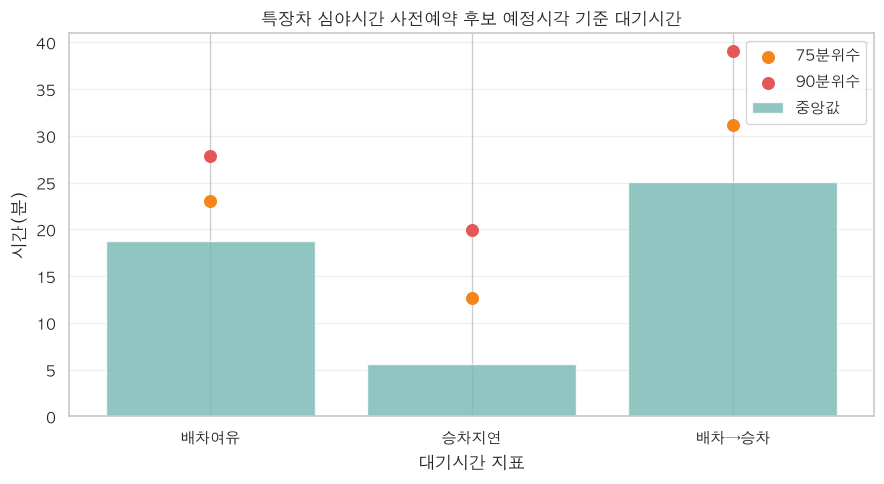

In [73]:
# 코드 셀 목적: 특장차 심야시간 사전예약 후보의 예정시각 기준 배차여유·승차지연·배차후 승차시간을 확인한다.

night_reservation_data = special_ride_night_reservation.copy()

night_reservation_data["예정일시"] = pd.to_datetime(
    night_reservation_data["예정일시"],
    errors="coerce",
)
night_reservation_data["배차일시"] = pd.to_datetime(
    night_reservation_data["배차일시"],
    errors="coerce",
)
night_reservation_data["승차일시"] = pd.to_datetime(
    night_reservation_data["승차일시"],
    errors="coerce",
)

night_reservation_data["배차_승차_분"] = pd.to_numeric(
    night_reservation_data["배차_승차_분"],
    errors="coerce",
)

night_reservation_data["배차여유_분"] = (
    night_reservation_data["예정일시"] - night_reservation_data["배차일시"]
).dt.total_seconds() / 60

night_reservation_data["승차지연_분"] = (
    night_reservation_data["승차일시"] - night_reservation_data["예정일시"]
).dt.total_seconds() / 60

night_wait_cols = ["배차여유_분", "승차지연_분", "배차_승차_분"]
night_wait_labels = {
    "배차여유_분": "배차여유",
    "승차지연_분": "승차지연",
    "배차_승차_분": "배차→승차",
}

night_wait_summary = []

for col in night_wait_cols:
    values = night_reservation_data[col].dropna()
    night_wait_summary.append({
        "구간": night_wait_labels[col],
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "최소값": values.min(),
        "최대값": values.max(),
    })

night_wait_summary = pd.DataFrame(night_wait_summary)
display(night_wait_summary)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(night_wait_summary))

ax.bar(
    x,
    night_wait_summary["중앙값"],
    color="#76b7b2",
    alpha=0.8,
    label="중앙값",
)

ax.scatter(
    x,
    night_wait_summary["75분위수"],
    color="#f58518",
    s=70,
    label="75분위수",
    zorder=3,
)

ax.scatter(
    x,
    night_wait_summary["90분위수"],
    color="#e45756",
    s=70,
    label="90분위수",
    zorder=3,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("특장차 심야시간 사전예약 후보 예정시각 기준 대기시간")
ax.set_xlabel("대기시간 지표")
ax.set_ylabel("시간(분)")
ax.set_xticks(list(x))
ax.set_xticklabels(night_wait_summary["구간"])
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

,대기시간구간,건수,평균,중앙값,p75,p90,p95,최소값,최대값
0,배차_승차_분,116,26.146621,25.086892,31.199013,39.032008,44.601729,6.804383,58.680550
1,배차여유_분,116,18.850311,18.798892,23.033071,27.826500,34.393637,-9.742783,51.106717
2,승차지연_분,116,7.296310,5.654950,12.669167,19.925083,28.593567,-23.191883,49.003167


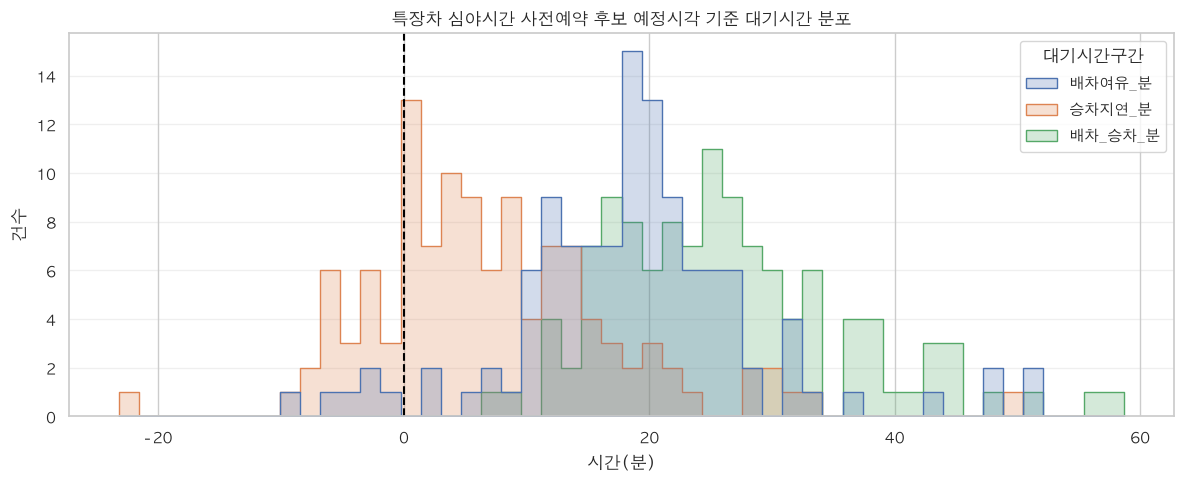

In [74]:
# 코드 셀 목적: 특장차 심야시간 사전예약 후보의 예정시각 기준 대기시간 분포를 히스토그램으로 시각화한다.

night_wait_long = (
    night_reservation_data[["배차여유_분", "승차지연_분", "배차_승차_분"]]
    .melt(var_name="대기시간구간", value_name="대기시간(분)")
    .dropna()
)

night_wait_long = night_wait_long[
    night_wait_long["대기시간(분)"].between(-60, 180)
].copy()

night_distribution_summary = (
    night_wait_long
    .groupby("대기시간구간", observed=False)
    .agg(
        건수=("대기시간(분)", "count"),
        평균=("대기시간(분)", "mean"),
        중앙값=("대기시간(분)", "median"),
        p75=("대기시간(분)", lambda x: x.quantile(0.75)),
        p90=("대기시간(분)", lambda x: x.quantile(0.90)),
        p95=("대기시간(분)", lambda x: x.quantile(0.95)),
        최소값=("대기시간(분)", "min"),
        최대값=("대기시간(분)", "max"),
    )
    .reset_index()
)

display(night_distribution_summary)

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=night_wait_long,
    x="대기시간(분)",
    hue="대기시간구간",
    bins=50,
    element="step",
    stat="count",
    common_norm=False,
    ax=ax,
)

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="예정시각")
ax.set_title("특장차 심야시간 사전예약 후보 예정시각 기준 대기시간 분포")
ax.set_xlabel("시간(분)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

1. 파란색 `배차여유_분`은 주로 `15~25분` 근처에 몰려 있음
   - `배차여유_분 = 예정일시 - 배차일시` => 양수는 예정시각보다 먼저 배차됐다는 의미
   - 심야시간 사전예약 후보는 전일접수와 달리 예정시각보다 `15~25분` 정도 미리 배차되는 경우가 많아 보임

2. 주황색 `승차지연_분`은 `0~10분` 근처와 음수 구간에도 일부 분포
   - `승차지연_분 = 승차일시 - 예정일시` => 양수는 예정시각보다 늦게 승차, 음수는 예정시각보다 먼저 승차를 의미
   - 전반적으로 예정시각 직후 또는 그보다 이른 승차가 적지 않게 나타남
   - 심야시간 사전예약이 실제 탑승시각에 맞춰 비교적 미리 배차되고 이용자가 예정시각 전후로 탑승하는 구조일 가능성

3. 초록색 `배차→승차`는 `15~35분` 정도로 넓게 퍼져 있음
   - 배차 후 실제 승차까지 걸리는 시간이 전일접수보다 다소 길거나 변동성이 커 보암
   - 심야시간에는 차량 접근 거리, 운행 가능 차량 수, 심야 도로 및 대기 조건 등이 영향을 줄 수 있음

4. 해석 시 표본 수에 주의해야 함
   - 심야시간 사전예약 후보는 건수가 `116건`으로 작음
   - 따라서 이 그래프는 전일접수처럼 일반화하기보다는 후보군의 패턴을 확인하는 참고 지표로 해석하는 것이 안전

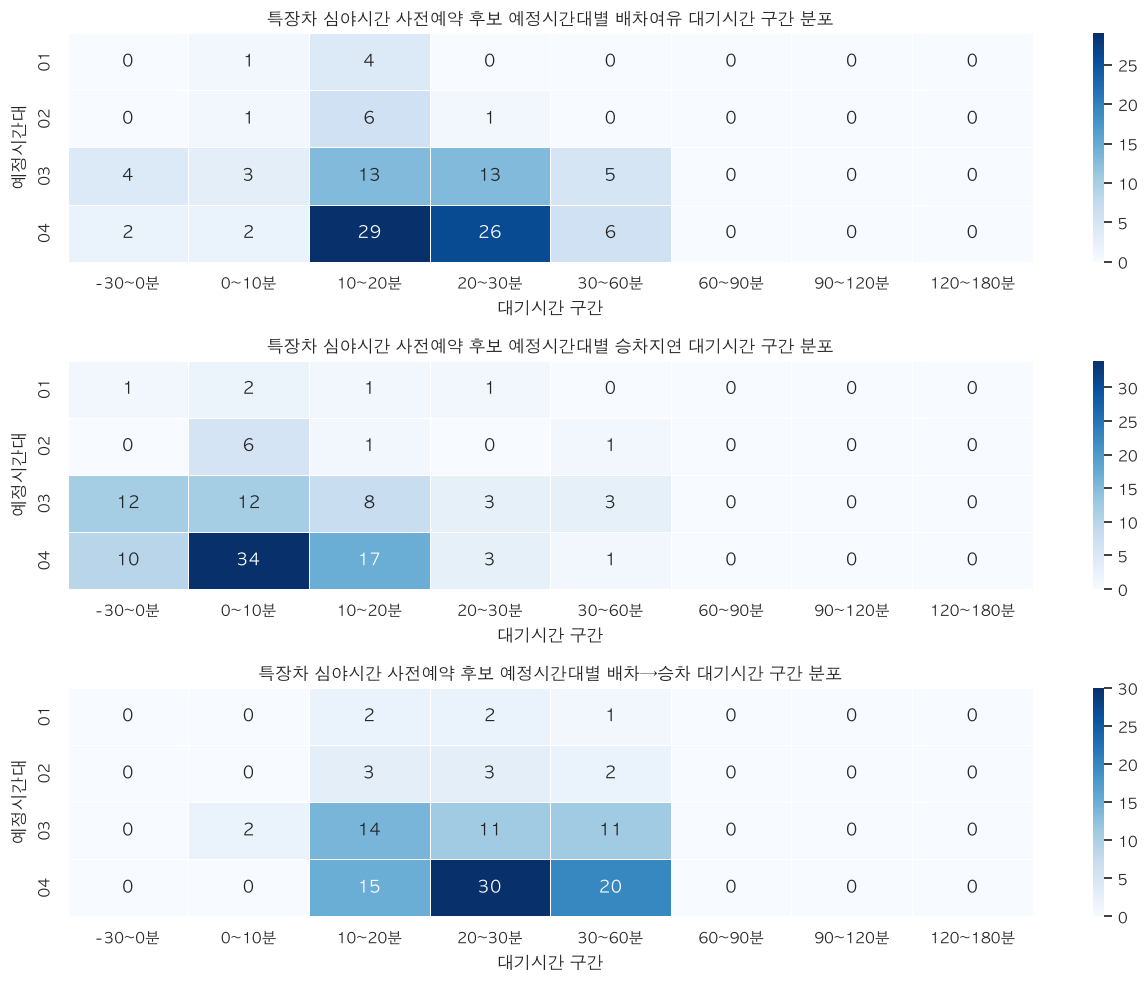

In [75]:
# 코드 셀 목적: 특장차 심야시간 사전예약 후보의 예정시간대별 배차여유·승차지연·배차후 승차시간 구간 분포를 히트맵으로 시각화한다.

night_heatmap_data = night_reservation_data.copy()

night_heatmap_data["예정일시"] = pd.to_datetime(
    night_heatmap_data["예정일시"],
    errors="coerce",
)
night_heatmap_data["예정시간대_HH"] = (
    night_heatmap_data["예정일시"].dt.strftime("%H")
)

night_heatmap_data["배차여유_분"] = pd.to_numeric(
    night_heatmap_data["배차여유_분"],
    errors="coerce",
)
night_heatmap_data["승차지연_분"] = pd.to_numeric(
    night_heatmap_data["승차지연_분"],
    errors="coerce",
)
night_heatmap_data["배차_승차_분"] = pd.to_numeric(
    night_heatmap_data["배차_승차_분"],
    errors="coerce",
)

wait_bins = [-30, 0, 10, 20, 30, 60, 90, 120, 180]
wait_labels = [
    "-30~0분",
    "0~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
]

heatmap_specs = [
    ("배차여유_분", "배차여유"),
    ("승차지연_분", "승차지연"),
    ("배차_승차_분", "배차→승차"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

for ax, (col, title) in zip(axes, heatmap_specs):
    plot_data = night_heatmap_data.dropna(
        subset=["예정시간대_HH", col]
    ).copy()

    plot_data["대기시간구간"] = pd.cut(
        plot_data[col],
        bins=wait_bins,
        labels=wait_labels,
        right=True,
        include_lowest=True,
    )

    heatmap_data = (
        plot_data
        .dropna(subset=["대기시간구간"])
        .pivot_table(
            index="예정시간대_HH",
            columns="대기시간구간",
            values=col,
            aggfunc="count",
            observed=False,
        )
        .reindex(columns=wait_labels)
        .fillna(0)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        linewidths=0.5,
        ax=ax,
    )

    ax.set_title(f"특장차 심야시간 사전예약 후보 예정시간대별 {title} 대기시간 구간 분포")
    ax.set_xlabel("대기시간 구간")
    ax.set_ylabel("예정시간대")

plt.tight_layout()
plt.show()

핵심은 심야시간 사전예약 후보는 03~04시에 대부분 몰리고, 배차는 예정시각보다 10~30분 정도 미리 되는 경우가 많지만 실제 승차는 예정시각 전후 또는 10분 이내에 이루어지는 경우가 많다는 점

1. `배차여유`는 03시와 04시에 집중되어 있음
   - 첫 번째 `배차여유` 히트맵을 보면 03시와 04시에 건수가 집중됨
   - 심야시간 사전예약은 대체로 예정시각보다 `10~30분` 전에 배차되는 경우가 많음

2. `승차지연`은 예정시각 전후 또는 10분 이내에 많이 분포
   - 두 번째 `승차지연` 히트맵을 보면 04시는 `0~10분`이 34건으로 가장 많음.
   - 실제 승차는 예정시각보다 조금 빠르거나 예정시각 이후 `10분 이내`에 이루어지는 경우가 많음
   - 전일접수처럼 `20~30분` 지연이 중심인 구조와는 다른 패턴

3. `배차→승차`는 10~60분 구간에 분산되어 있음
   - 세 번째 `배차→승차` 히트맵을 보면 03시는 `10~20분`, `20~30분`, `30~60분` 구간에 분산되어 있음
   - 배차 자체는 미리 이루어지지만 배차 후 실제 승차까지는 `20~60분`까지 퍼져 있음
   - 심야시간 특성상 차량이 미리 배정되어도 실제 탑승까지 대기 또는 접근 시간이 존재한다는 의미로 볼 수 있음

## 6. 취소 대기시간 분석

취소 건은 승차일시가 없을 수 있으므로 승차 완료 접수유형 후보와 같은 방식으로 확정 분류하지 않는다. 우선 특장차 취소 전체를 대상으로 `접수→취소`, `배차→취소` 시간을 확인한다.


In [ ]:
# 코드 셀 목적: 특장차 취소 전체의 취소 대기시간 요약과 배차 전후 취소 건수를 확인한다.

cancel_wait_summary = []
for col in ["접수_취소_분", "배차_취소_분"]:
    values = special_cancel[col].dropna()
    cancel_wait_summary.append({
        "구간": col.replace("_", "→").replace("분", "").rstrip("→"),
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "99분위수": values.quantile(0.99),
        "최대값": values.max(),
    })

cancel_dispatch_summary = pd.DataFrame({
    "구분": ["취소 전체", "배차 후 취소", "배차 전 취소 또는 배차일시 미기록 취소"],
    "건수": [
        len(special_cancel),
        special_cancel["배차일시"].notna().sum(),
        special_cancel["배차일시"].isna().sum(),
    ],
})
cancel_dispatch_summary["비율(%)"] = cancel_dispatch_summary["건수"] / len(special_cancel) * 100

display(pd.DataFrame(cancel_wait_summary))
display(cancel_dispatch_summary)


## 7. 접수시간대별 대기시간 분석

접수시간대별로 바로콜 후보의 `접수→배차`, `접수→승차`, `배차→승차` 90분위수를 확인한다. 90분위수는 평균보다 극단값 영향이 작으면서 장시간 대기 구간을 볼 수 있는 지표다.


In [ ]:
# 코드 셀 목적: 특장차 바로콜 후보의 접수시간대별 대기시간을 집계하고 시각화한다.

hourly_baro_summary = (
    special_ride_baro_call
    .groupby("접수시간대", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
    .sort_values("접수시간대")
)

hourly_baro_summary["접수시간대_HH"] = hourly_baro_summary["접수시간대"].astype(str).str.slice(0, 2)

display(hourly_baro_summary)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_baro_summary["접수시간대_HH"], hourly_baro_summary["접수_배차_90분위수"], marker="o", label="접수→배차 90분위수")
ax.plot(hourly_baro_summary["접수시간대_HH"], hourly_baro_summary["배차_승차_90분위수"], marker="o", label="배차→승차 90분위수")
ax.set_title("특장차 바로콜 후보 접수시간대별 장시간 대기 원인 비교")
ax.set_xlabel("접수시간대")
ax.set_ylabel("90분위수 대기시간(분)")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 8. 요일별 대기시간 분석

요일별로 특장차 바로콜 후보의 승차 완료건수와 대기시간을 비교한다. 평일과 주말은 이용 목적과 차량 운영 패턴이 다를 수 있다.


In [ ]:
# 코드 셀 목적: 특장차 바로콜 후보의 요일별 승차완료건수와 대기시간을 확인한다.

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]
special_ride_baro_call["접수요일"] = pd.Categorical(
    special_ride_baro_call["접수요일"],
    categories=weekday_order,
    ordered=True,
)

weekday_baro_summary = (
    special_ride_baro_call
    .groupby("접수요일", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(weekday_baro_summary)


## 9. 출발구별·이동유형별 대기시간 분석

출발구와 세부이동유형을 함께 보아 지역별 차량 접근성과 광역 이동 부담을 확인한다.


## 10. 승차거리에 따른 대기시간 분석

승차거리가 길어질수록 배차가 늦어지는지 확인한다. 장거리 이동은 기사 입장에서 운행 및 회차 부담이 커질 수 있으므로 `접수→배차`를 핵심 지표로 본다.


In [ ]:
# 코드 셀 목적: 승차거리구간별 특장차 바로콜 후보의 대기시간을 확인한다.

distance_baro_summary = (
    special_ride_baro_call
    .groupby("승차거리구간", observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(distance_baro_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distance_baro_summary["승차거리구간"].astype(str), distance_baro_summary["접수_배차_90분위수"], marker="o", label="접수→배차 90분위수")
ax.plot(distance_baro_summary["승차거리구간"].astype(str), distance_baro_summary["접수_승차_90분위수"], marker="o", label="접수→승차 90분위수")
ax.set_title("특장차 바로콜 후보 승차거리구간별 대기시간")
ax.set_xlabel("승차거리구간")
ax.set_ylabel("대기시간(분)")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 코드 셀 목적: 출발구별·세부이동유형별 접수→배차 90분위수와 승차완료건수를 확인한다.

district_movement_baro_summary = (
    special_ride_baro_call
    .groupby(["출발구", "세부이동유형"], observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(district_movement_baro_summary.sort_values(["접수_배차_90분위수", "승차완료건수"], ascending=False).head(30))

heatmap_data = district_movement_baro_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_90분위수",
    aggfunc="median",
)

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5, ax=ax)
ax.set_title("특장차 바로콜 후보 출발구별·이동유형별 접수→배차 90분위수")
ax.set_xlabel("세부이동유형")
ax.set_ylabel("출발구")
plt.tight_layout()
plt.show()


## 11. 장시간 대기 건 특징 분석

바로콜 후보 중 `접수→배차` 90분위수 이상인 장시간 대기 건이 특정 시간대, 요일, 지역, 이동유형, 승차거리구간에 집중되는지 확인한다.


In [ ]:
# 코드 셀 목적: 특장차 바로콜 후보 중 접수→배차 장시간 대기 건의 특징을 확인한다.

dispatch_delay_cutoff = special_ride_baro_call["접수_배차_분"].quantile(0.90)
long_dispatch_baro = special_ride_baro_call[
    special_ride_baro_call["접수_배차_분"].ge(dispatch_delay_cutoff)
].copy()

print(f"접수→배차 장시간 기준(90분위수): {dispatch_delay_cutoff:.1f}분")
print(f"장시간 대기 건수: {len(long_dispatch_baro):,}건")

feature_cols = ["접수시간대", "접수요일", "출발구", "세부이동유형", "승차거리구간"]
for col in feature_cols:
    print(f"\n[{col}]")
    display(
        long_dispatch_baro[col]
        .value_counts(dropna=False)
        .reset_index(name="장시간대기건수")
        .head(20)
    )


## 12. 취소율과 대기시간 관계 분석

취소율은 승차 완료건수와 취소건수를 함께 보아야 한다. 이 단계에서는 접수시간대, 요일, 출발구, 세부이동유형별 취소율을 확인한다.


In [ ]:
# 코드 셀 목적: 조건별 특장차 취소율을 계산한다.

def summarize_cancel_rate(ride_df, cancel_df, group_col):
    ride_summary = (
        ride_df.groupby(group_col, observed=False)
        .size()
        .reset_index(name="승차완료건수")
    )
    cancel_summary = (
        cancel_df.groupby(group_col, observed=False)
        .size()
        .reset_index(name="취소건수")
    )
    summary = ride_summary.merge(cancel_summary, on=group_col, how="outer")
    summary["승차완료건수"] = summary["승차완료건수"].fillna(0).astype(int)
    summary["취소건수"] = summary["취소건수"].fillna(0).astype(int)
    summary["전체접수건수"] = summary["승차완료건수"] + summary["취소건수"]
    summary["취소율(%)"] = summary["취소건수"] / summary["전체접수건수"] * 100
    return summary.sort_values(["취소율(%)", "전체접수건수"], ascending=False).reset_index(drop=True)

cancel_rate_by_hour = summarize_cancel_rate(special_ride_baro_call, special_cancel, "접수시간대")
cancel_rate_by_weekday = summarize_cancel_rate(special_ride_baro_call, special_cancel, "접수요일")
cancel_rate_by_district = summarize_cancel_rate(special_ride_baro_call, special_cancel, "출발구")
cancel_rate_by_movement = summarize_cancel_rate(special_ride_baro_call, special_cancel, "세부이동유형")

display(cancel_rate_by_hour)
display(cancel_rate_by_weekday)
display(cancel_rate_by_district.head(20))
display(cancel_rate_by_movement)


## 13. 배차 지연형과 배차 후 지연형 분리

바로콜 후보의 장시간 대기가 차량 배정 단계에서 발생하는지, 배차 후 차량 접근 단계에서 발생하는지 분리한다.


In [ ]:
# 코드 셀 목적: 특장차 바로콜 후보의 지연유형을 접수→배차와 배차→승차 90분위수 기준으로 분리한다.

dispatch_delay_cutoff = special_ride_baro_call["접수_배차_분"].quantile(0.90)
pickup_delay_cutoff = special_ride_baro_call["배차_승차_분"].quantile(0.90)

special_ride_baro_call["접수_배차_장시간여부"] = special_ride_baro_call["접수_배차_분"].ge(dispatch_delay_cutoff)
special_ride_baro_call["배차_승차_장시간여부"] = special_ride_baro_call["배차_승차_분"].ge(pickup_delay_cutoff)

special_ride_baro_call["지연유형"] = "일반"
special_ride_baro_call.loc[
    special_ride_baro_call["접수_배차_장시간여부"] & ~special_ride_baro_call["배차_승차_장시간여부"],
    "지연유형",
] = "배차 지연형"
special_ride_baro_call.loc[
    ~special_ride_baro_call["접수_배차_장시간여부"] & special_ride_baro_call["배차_승차_장시간여부"],
    "지연유형",
] = "배차 후 지연형"
special_ride_baro_call.loc[
    special_ride_baro_call["접수_배차_장시간여부"] & special_ride_baro_call["배차_승차_장시간여부"],
    "지연유형",
] = "복합 지연형"

delay_type_summary = (
    special_ride_baro_call
    .groupby("지연유형", observed=False)
    .agg(
        건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)
delay_type_summary["비율(%)"] = delay_type_summary["건수"] / delay_type_summary["건수"].sum() * 100

display(delay_type_summary.sort_values("건수", ascending=False))
